## Key findings

---

### Dataset Structure

- **14.7M training rows** (≈14 years, sampled every 30 s) + **521K test rows** (≈6 months)
- **76 sensor channels** + **11 telecommand flags** → **58 channels are scored** by the competition metric
- **Zero missing values** - no imputation needed anywhere

---

### Anomaly Distribution

- **10.5% of all samples** are anomalous - but dominated by a few very long events
- **190 anomaly events** total; the 80/20 temporal split leaves **38 events in validation** (the benchmark for all models)
- Event lengths span an extreme range: **shortest = 1 sample, longest = 116,061 samples, median = 602**
- Anomaly rates are consistent across splits: fit 10.47% / val 10.53%

**Consequence:** A model only needs to tag 1 sample per event to score a TP. The metric penalises spurious segments and false-alarm density heavily - precision matters more than recall.

---

### Channel Characteristics

| Group | What it means for modelling |
|---|---|
| Channels 4–11 | Pre-differenced by ESA (odometer counters → hover near zero). **Do not difference again** |
| Top discriminative channels | channel_16, channel_32 show Cohen's d ≈ 0.33 - moderate mean separation between nominal and anomaly |
| High-variance channels | Some channels signal anomalies through **increased noise**, not level shifts - both patterns must be captured |
| Block correlations | Strong correlation clusters among channel groups → low-dimensional nominal manifold → PCA is a natural fit |

---

### Train vs Test Distribution Shift - Critical Finding

- **Mean KS distance across 58 channels = 0.43** - distributions are substantially different between train and test
- **Top shifted channels**: channel_15 (KS = 0.97), channel_23 (0.97), channel_38 (0.97) - nearly completely separated
- These channels have much higher means in test than in train (e.g. channel_14: train mean 0.27 → test mean 0.64)

**Direct consequence for scoring strategy:**

| Scoring | Val max score | Test max score | Ratio | Kaggle result |
|---|---|---|---|---|
| `window_mean` MSE | ≈ 1,178 | ≈ 1.31 | ~900× - same order of magnitude | **0.522 ✓** |
| `per_row/max` MSE | ≈ 19,528 | ≈ 124.7 | 157× gap | **0.277 ✗** |

The `per_row/max` val threshold sits above 99.99% of test scores → only 4 test rows flagged → score collapse.

---

### Telecommand Co-occurrence

- All 11 telecommands fire with **lift > 6× inside anomaly windows** (most ≈ 9.5×)
- Absolute firing counts are tiny (≤ 56 total across 14.7M rows)
- **Interpretation:** operators respond to faults by sending commands - telecommands are a *consequence* of anomalies, not a causal predictor

---

### Implications for Modelling

1. **Fit on nominal data only** - 89.5% of rows are nominal; the detector learns the normal manifold
2. **Window-mean reconstruction is the only stable scoring strategy** - smooths per-row outliers that don't transfer across mission phases
3. **PCA ceiling is real** - 17/38 val events missed because they have genuinely low reconstruction error in the linear subspace; a non-linear model is needed to recover them
4. **Window size is a critical hyperparameter** - too short misses context, too long dilutes short events (median length: 602 rows)

---

## Imports & Data load

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

from sentinel.ml_logic.data import (
    load_train, load_test, load_target_channels,
    find_anomaly_segments, get_channel_cols, get_telecommand_cols
)
from sentinel.ml_logic.metrics import corrected_event_f05
from sentinel.params import ANOMALY_COLOR, NOMINAL_COLOR

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

In [29]:
train = load_train()
test  = load_test()
target_channels = load_target_channels()

channel_cols     = get_channel_cols(train)
telecommand_cols = get_telecommand_cols(train)

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
print(f'Channel cols       : {len(channel_cols)}')
print(f'Telecommand cols   : {len(telecommand_cols)}')
print(f'Target channels    : {len(target_channels)}')
print(f'Train ID range     : {train["id"].min():,} → {train["id"].max():,}')
print(f'Test  ID range     : {test["id"].min():,} → {test["id"].max():,}')

Train shape : (14728321, 89)
Test shape  : (521280, 88)
Channel cols       : 76
Telecommand cols   : 11
Target channels    : 58
Train ID range     : 0 → 14,728,320
Test  ID range     : 14,728,321 → 15,249,600


## Naive Baseline: predict all zeros → what F0.5 would we get?

In [30]:
n_total   = len(train)
n_anomaly = int(train['is_anomaly'].sum())
n_nominal = n_total - n_anomaly

print(f'Total samples  : {n_total:>12,}')
print(f'Nominal        : {n_nominal:>12,}  ({n_nominal/n_total*100:.2f}%)')
print(f'Anomaly        : {n_anomaly:>12,}  ({n_anomaly/n_total*100:.2f}%)')

Total samples  :   14,728,321
Nominal        :   13,184,217  (89.52%)
Anomaly        :    1,544,104  (10.48%)


In [31]:
all_zeros = np.zeros(n_total, dtype=np.int8)
baseline_result = corrected_event_f05(train['is_anomaly'].values, all_zeros)

print('=== Baseline: predict ALL NOMINAL (all-zeros) ===')
for k, v in baseline_result.items():
    print(f'  {k:<15}: {v}')

=== Baseline: predict ALL NOMINAL (all-zeros) ===
  f_score        : 0.0
  precision      : 0.0
  recall         : 0.0
  tp_events      : 0
  fn_events      : 190
  fp_pred_events : 0
  fp_samples     : 0
  tnr            : 1.0


## Channels 

### Most interesting channels

In [32]:
# Most interesting channels: top by mean shift (Cohen's d) + top by variance amplification (std ratio)

_nom  = train[train['is_anomaly'] == 0]
_anom = train[train['is_anomaly'] == 1]

_stats = pd.DataFrame({
    'nom_mean':  _nom[target_channels].mean(),
    'anom_mean': _anom[target_channels].mean(),
    'nom_std':   _nom[target_channels].std(),
    'anom_std':  _anom[target_channels].std(),
})
_stats['cohens_d']  = (
    (_stats['anom_mean'] - _stats['nom_mean']).abs()
    / np.sqrt((_stats['nom_std']**2 + _stats['anom_std']**2) / 2)
)
_stats['std_ratio'] = _stats['anom_std'] / _stats['nom_std'].replace(0, np.nan)

TOP_MEAN = _stats.sort_values('cohens_d',  ascending=False).head(6).index.tolist()
TOP_VAR  = _stats.sort_values('std_ratio', ascending=False).head(6).index.tolist()

OVERVIEW_CHANNELS = list(dict.fromkeys(TOP_MEAN + TOP_VAR))  # dedupe, preserve order

print(f'Top 6 by Cohen\'s d (mean shift):       {TOP_MEAN}')
print(f'Top 6 by std_ratio (variance amplif.): {TOP_VAR}')
print(f'\nOVERVIEW_CHANNELS ({len(OVERVIEW_CHANNELS)}): {OVERVIEW_CHANNELS}')


Top 6 by Cohen's d (mean shift):       ['channel_16', 'channel_32', 'channel_40', 'channel_24', 'channel_33', 'channel_59']
Top 6 by std_ratio (variance amplif.): ['channel_64', 'channel_65', 'channel_48', 'channel_49', 'channel_47', 'channel_66']

OVERVIEW_CHANNELS (12): ['channel_16', 'channel_32', 'channel_40', 'channel_24', 'channel_33', 'channel_59', 'channel_64', 'channel_65', 'channel_48', 'channel_49', 'channel_47', 'channel_66']


### Full time range overview

In [33]:
# Pick a representative subset of channels for overview plots
# Use target_channels first 12 for compactness, then sample others
# OVERVIEW_CHANNELS = target_channels[:12]

# Channel 41-46
OVERVIEW_CHANNELS = [f'channel_{i}' for i in range(41, 47)]

# Top 6 by Cohen's d (mean shift):
# OVERVIEW_CHANNELS = ['channel_16', 'channel_32', 'channel_40', 'channel_24', 'channel_33', 'channel_59']

print(f'Plotting channels: {OVERVIEW_CHANNELS}')

Plotting channels: ['channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46']


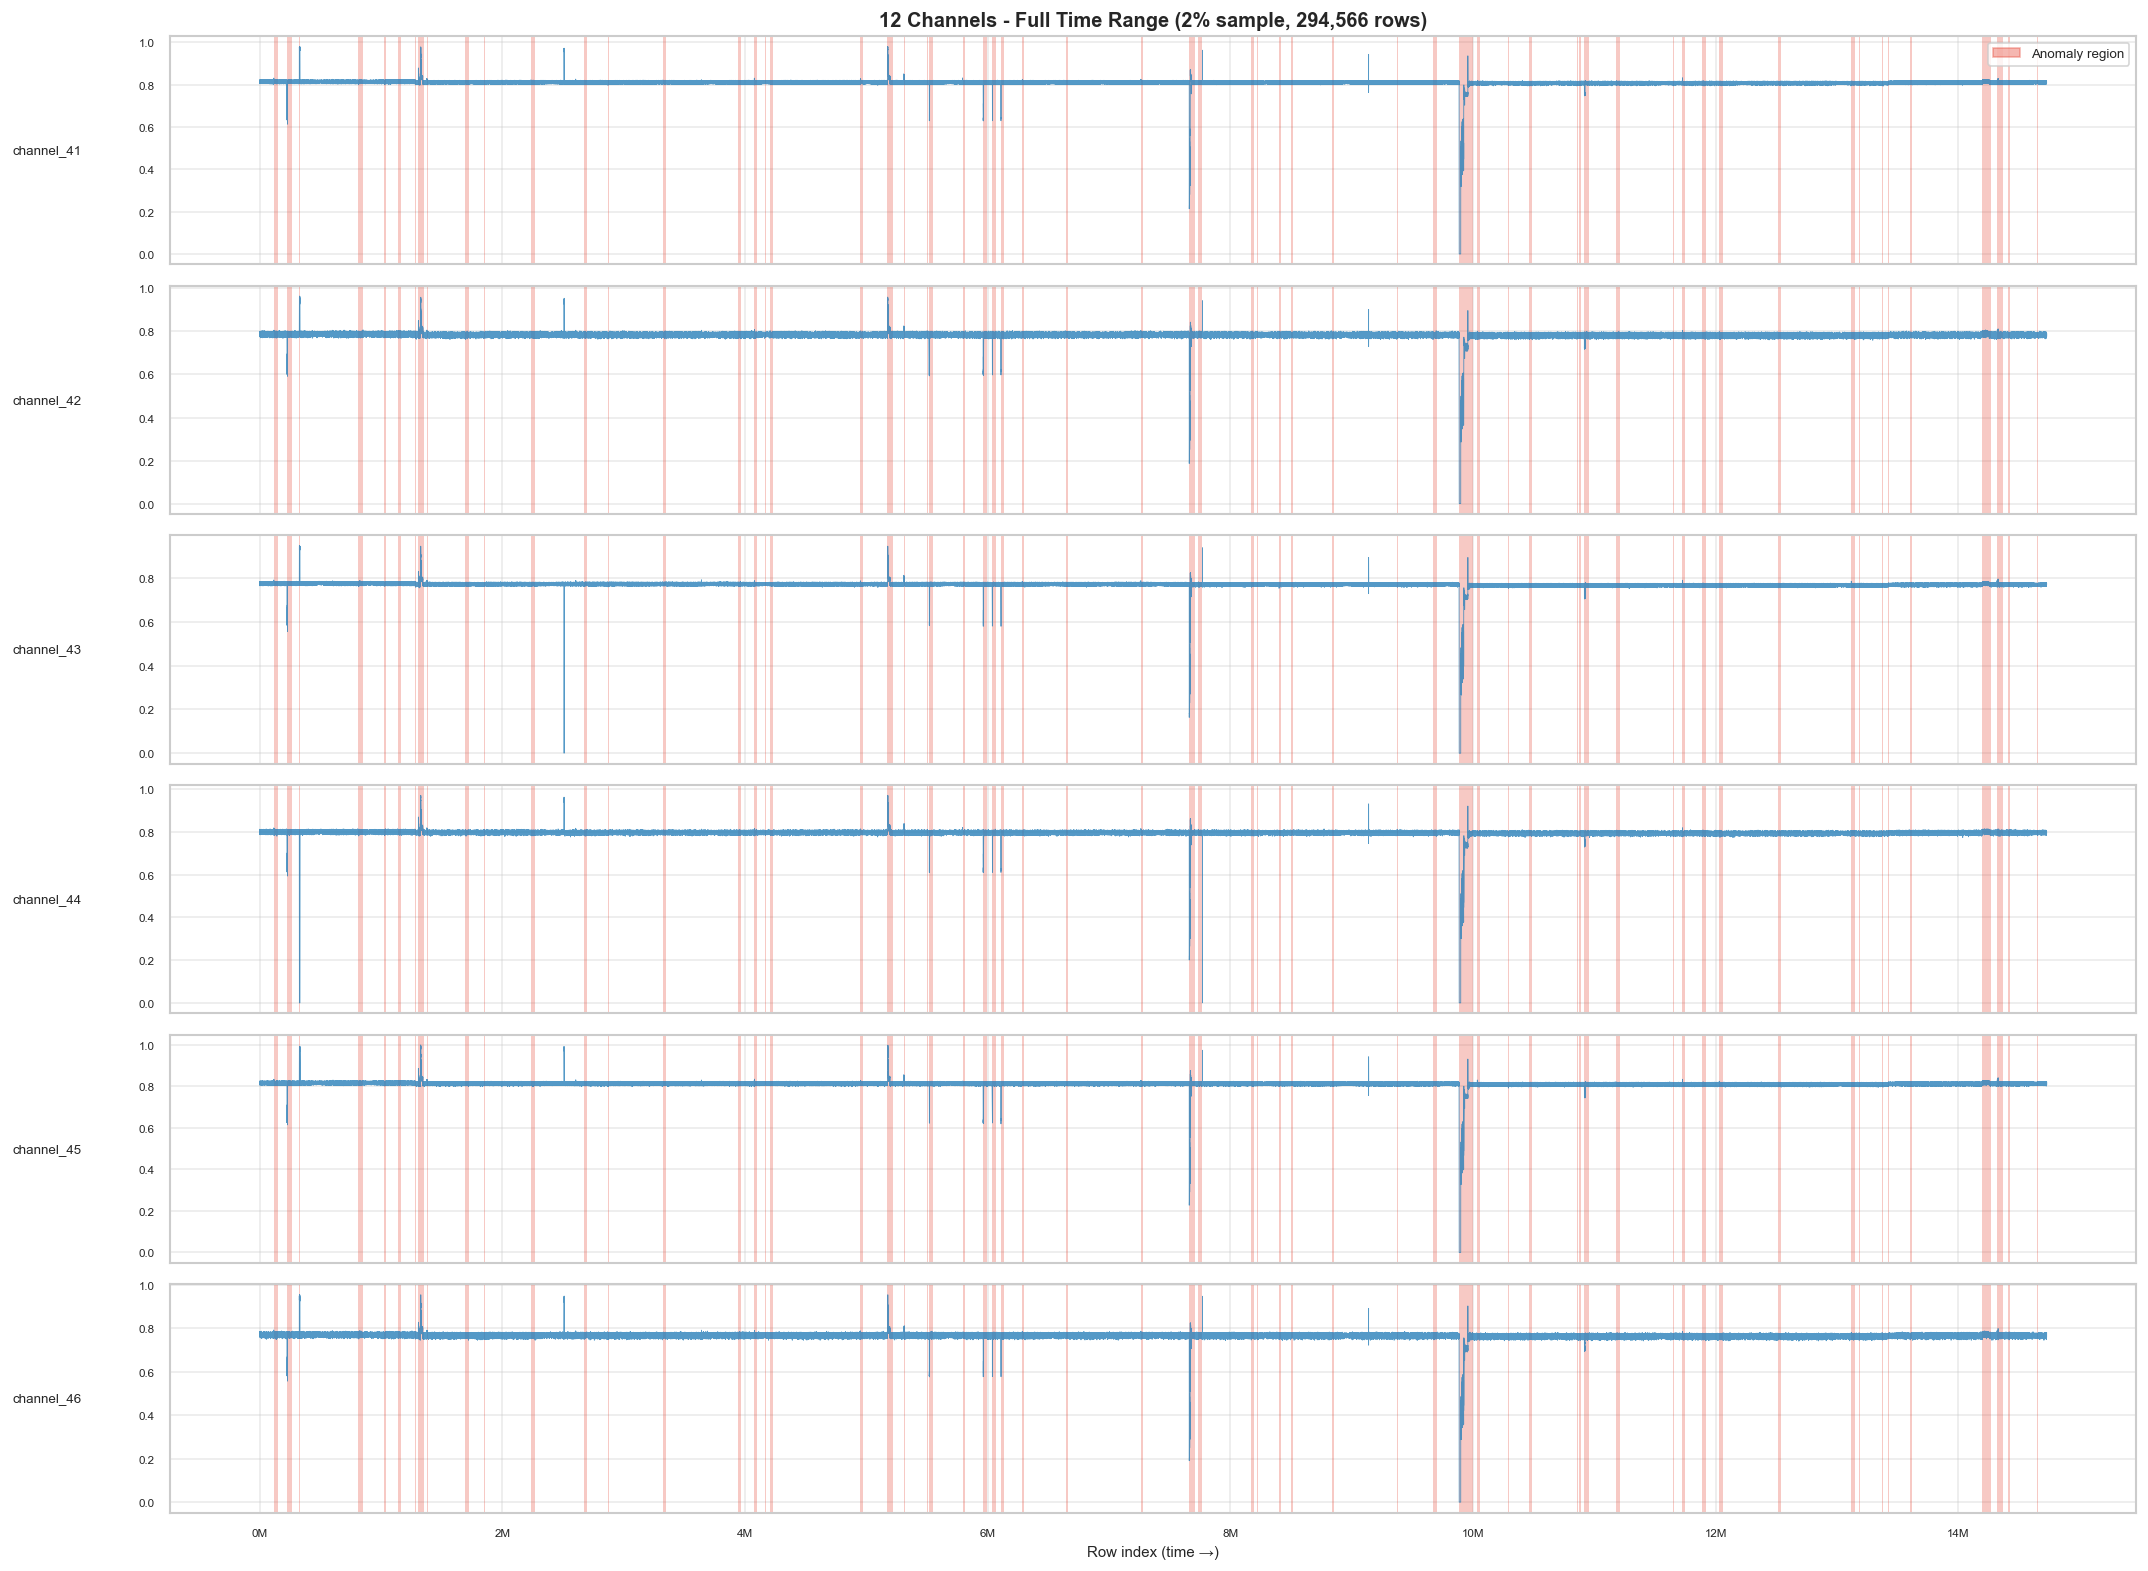

In [34]:
# Full time range overview - downsampled for display
SAMPLE_FRAC = 0.02   # 2% ≈ 295k rows - enough to see the shape
train_s = train.sample(frac=SAMPLE_FRAC, random_state=42).sort_index()

n_ch = len(OVERVIEW_CHANNELS)
fig, axes = plt.subplots(n_ch, 1, figsize=(18, 2.2 * n_ch), sharex=True)

for ax, ch in zip(axes, OVERVIEW_CHANNELS):
    ax.plot(train_s.index, train_s[ch].values, lw=0.5, color=NOMINAL_COLOR, alpha=0.8)
    # shade anomaly regions
    in_anom = False
    start_i = None
    idx_arr = train_s.index.values
    lab_arr = train_s['is_anomaly'].values
    for i, (ix, v) in enumerate(zip(idx_arr, lab_arr)):
        if v == 1 and not in_anom:
            start_i = ix
            in_anom = True
        elif v == 0 and in_anom:
            ax.axvspan(start_i, ix, color=ANOMALY_COLOR, alpha=0.3, linewidth=0)
            in_anom = False
    if in_anom:
        ax.axvspan(start_i, idx_arr[-1], color=ANOMALY_COLOR, alpha=0.3, linewidth=0)
    ax.set_ylabel(ch, fontsize=8, rotation=0, labelpad=55, va='center')
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.4)

axes[0].set_title(
    f'12 Channels - Full Time Range (2% sample, {len(train_s):,} rows)',
    fontsize=12, fontweight='bold'
)
axes[-1].set_xlabel('Row index (time →)', fontsize=9)
axes[-1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

anom_patch = mpatches.Patch(color=ANOMALY_COLOR, alpha=0.4, label='Anomaly region')
axes[0].legend(handles=[anom_patch], fontsize=8, loc='upper right')
fig.tight_layout()
plt.show()

## Anomaly Statistics by Split
The 80/20 temporal split used for model training places **rows 0–SPLIT\_IDX** in the fit split (used to train the RobustScaler and PCA) and the remaining rows in the validation split. This section verifies the split produces a usable evaluation set and characterises the 38 val anomaly events that the baseline models are scored against.

SPLIT_IDX = 11,782,656
Fit  split : 11,782,656 rows  (80.0%)
Val  split :  2,945,665 rows  (20.0%)

Anomaly events - fit split : 152
Anomaly events - val split : 38
  ✓ 38 val events confirmed

Anomaly rate - fit : 10.47%
Anomaly rate - val : 10.53%


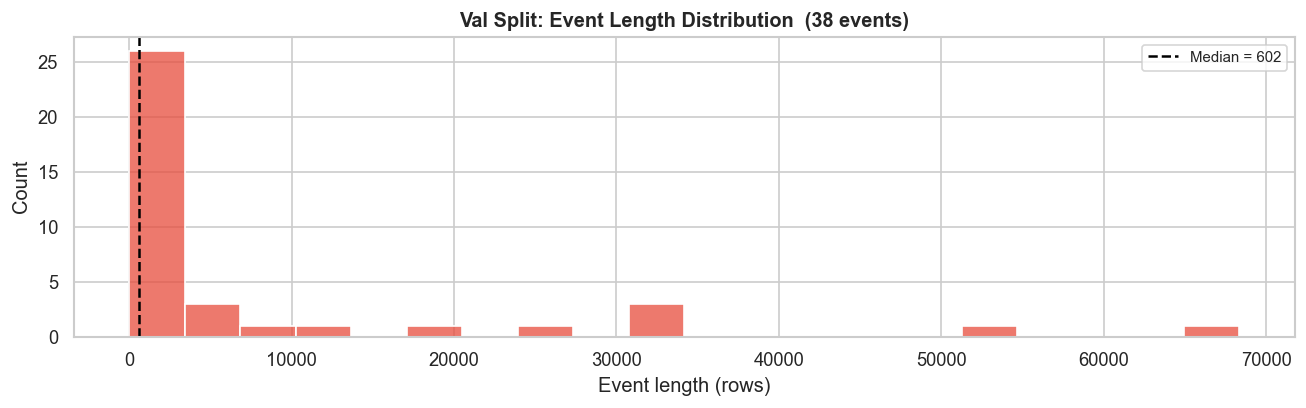


Val event length summary:
count       38.0
mean      8162.5
std      15905.7
min          1.0
25%         30.2
50%        601.5
75%       5025.0
max      68341.0


In [35]:
# ── 2.8  Split-aware Anomaly Statistics ──────────────────────────────────────
# Load SPLIT_IDX from preprocessing JSON so this stays in sync with notebook 02.

import json
from pathlib import Path

_split_json = Path('../data/processed/preprocessing_config.json')
if _split_json.exists():
    with open(_split_json) as _f:
        _cfg = json.load(_f)
    SPLIT_IDX = _cfg['split_idx']
else:
    SPLIT_IDX = int(0.8 * len(train))
    print(f'[WARN] preprocessing_config.json not found - using fallback SPLIT_IDX={SPLIT_IDX:,}')

print(f'SPLIT_IDX = {SPLIT_IDX:,}')

train_fit = train.iloc[:SPLIT_IDX]
val       = train.iloc[SPLIT_IDX:]
print(f'Fit  split : {len(train_fit):>10,} rows  ({len(train_fit)/len(train)*100:.1f}%)')
print(f'Val  split : {len(val):>10,} rows  ({len(val)/len(train)*100:.1f}%)')

segs_fit = find_anomaly_segments(train_fit['is_anomaly'])
segs_val = find_anomaly_segments(val['is_anomaly'])
print(f'\nAnomaly events - fit split : {len(segs_fit)}')
print(f'Anomaly events - val split : {len(segs_val)}')
assert len(segs_val) == 38, (
    f'Expected 38 val events (PCA baseline), got {len(segs_val)}'
)
print('  ✓ 38 val events confirmed')

fit_anom_rate = train_fit['is_anomaly'].mean() * 100
val_anom_rate = val['is_anomaly'].mean()  * 100
print(f'\nAnomaly rate - fit : {fit_anom_rate:.2f}%')
print(f'Anomaly rate - val : {val_anom_rate:.2f}%')

# Val event length histogram
segs_val_df = pd.DataFrame(segs_val)
fig, ax = plt.subplots(figsize=(11, 3.5))
sns.histplot(segs_val_df['length'], bins=20, ax=ax, color=ANOMALY_COLOR, edgecolor='white')
ax.set_xlabel('Event length (rows)')
ax.set_ylabel('Count')
ax.set_title(f'Val Split: Event Length Distribution  ({len(segs_val)} events)',
             fontweight='bold')
ax.axvline(segs_val_df['length'].median(), color='black', ls='--', lw=1.5,
           label=f'Median = {segs_val_df["length"].median():.0f}')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

print('\nVal event length summary:')
print(segs_val_df['length'].describe().round(1).to_string())